# Phases 4–6 — Modelling, Life Cycle, Interpretation

*A Machine Learning Approach to Predicting Firm Leverage in the UK Market*

Analysis code lives in `src/models.py`, `src/stage_models.py` and `src/shap_analysis.py`.
Regenerate everything with:

```bash
python -m src.models         # Phase 4
python -m src.stage_models   # Phase 5
python -m src.shap_analysis  # Phase 6
```

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
from IPython.display import Image, display
from src import config as C, viz
viz.apply_theme()
pd.set_option('display.width', 160)
FIG = C.OUTPUTS / 'figures'

## Phase 4 — model comparison

Split is chronological (train ≤2019, test 2020–2023). Every model sees identical rows
and columns; imputation is fitted on training data only; hyperparameters are tuned by
expanding-window CV inside the training period.

Two specifications: `with_lag` is the forecasting benchmark, `no_lag` answers RQ1.

In [2]:
m = pd.read_csv(C.OUTPUTS / 'tables' / 'model_metrics.csv')
m.pivot(index='model', columns='specification', values='r2').round(3).sort_values('no_lag', ascending=False)

specification,no_lag,with_lag
model,,
Random Forest,0.469,0.709
XGBoost,0.452,0.689
OLS,0.379,0.632
Lasso,0.378,0.627
Tobit,0.366,0.624
Naive (train mean),-0.011,-0.011
Naive (train median),-0.137,-0.137


### Is the gap over OLS real?

Bootstrapped by **firm**, not by row — a firm's four test-period years are not four
independent observations.

In [3]:
import warnings; warnings.filterwarnings('ignore')
from src.models import bootstrap_r2_gap

for spec in ['with_lag', 'no_lag']:
    p = pd.read_csv(C.OUTPUTS / f'predictions_{spec}.csv')
    g = bootstrap_r2_gap(p, 'XGBoost', 'OLS')
    print(f"{spec:9s} XGB-OLS {g['gap']:+.3f}  95% CI [{g['ci_low']:+.3f}, {g['ci_high']:+.3f}]  P={g['p_a_better']:.0%}")

with_lag  XGB-OLS +0.057  95% CI [+0.009, +0.115]  P=99%
no_lag    XGB-OLS +0.073  95% CI [+0.012, +0.145]  P=99%


## Phase 5 — life cycle heterogeneity

Each stage gets its own model, benchmarked against the **pooled model scored on the same
rows**. A raw within-stage R² would confound model quality with how predictable the stage is.

In [4]:
s = pd.read_csv(C.OUTPUTS / 'tables' / 'stage_metrics.csv')
s[(s.model=='XGBoost') & (s.specification=='no_lag')][
    ['stage','n_train','n_test','stage_r2','pooled_r2','gain']].round(3)

,stage,n_train,n_test,stage_r2,pooled_r2,gain
17,Introduction,3571,741,0.474,0.494,-0.019
20,Growth,2250,441,0.281,0.361,-0.080
23,Mature,4814,1351,0.573,0.630,-0.057
26,Shakeout,1586,431,0.330,0.566,-0.235
29,Decline,919,213,0.278,0.407,-0.129


The gain is negative in every stage: splitting the sample costs more in observations
than it gains in specificity. **One pooled model covers the life cycle better than five
separate ones** — which is why Phase 6 reads stage heterogeneity off the pooled model.

## Phase 6 — SHAP interpretation

### RQ1: which features predict leverage?

In [5]:
r = pd.read_csv(C.OUTPUTS / 'tables' / 'shap_global_ranking.csv', index_col=0)
r.head(12).round(4)

,mean_abs_shap,top10_stability
negative_book_equity,0.0752,1.0
altman_z,0.0533,1.0
cash_holdings,0.0344,1.0
size,0.0296,1.0
price_to_book,0.0223,1.0
tangibility,0.0144,1.0
market_to_book,0.0143,1.0
industry_median_leverage,0.0141,1.0
profitability,0.0119,1.0
ocf_to_assets,0.0074,1.0


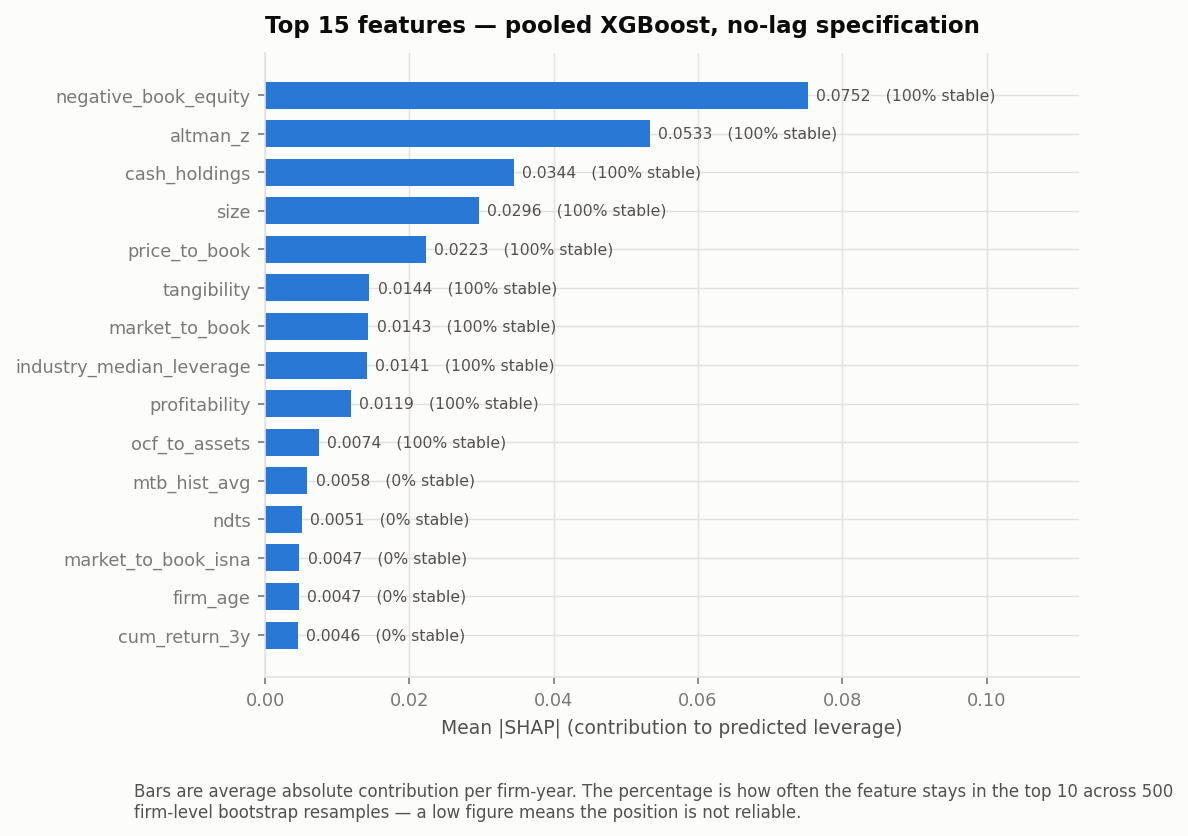

In [6]:
display(Image(filename=str(FIG / 'fig10_shap_global.png')))

### RQ2: does the ranking shift across the life cycle?

In [ ]:
display(Image(filename=str(FIG / 'fig11_shap_stage_shift.png')))

In [ ]:
ranks = pd.read_csv(C.OUTPUTS / 'tables' / 'shap_stage_ranks.csv', index_col=0)
ranks.loc[r.head(10).index]

The four leading features hold the same rank in **every** stage. Only the middle of the
ranking reshuffles. RQ2's answer is therefore qualified: the dominant drivers of leverage
are universal across the life cycle; stage dependence appears only among secondary features.

### Why the tree models win

In [ ]:
display(Image(filename=str(FIG / 'fig12_shap_dependence.png')))

`altman_z` has a sharp threshold near zero and `size` is curved at the low end. These are
the shapes a linear model cannot represent, and they are what the +0.07 R² over OLS buys.

---

Full write-ups: `outputs/model_report.md`, `outputs/stage_report.md`, `outputs/shap_report.md`.